<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 1: 데이터 분석**

## **미션 설명**

- 이번 단계에서는 다음과 같이 5개의 미션을 수행합니다.

### 미션 1: 기본 탐색 및 전처리

- 분석 대상 데이터를 읽어와 기본적인 탐색을 수행합니다.
- 결측치 존재 여부를 확인하고 적절한 방법으로 처리합니다.
- Target 값을 숫자로 변경합니다.
- 분석에 불필요한 변수를 제거합니다.

### 미션 2: 가설 수립과 검증

- 탐색 과정을 통해 얻은 정보로 가설을 수립합니다.
- 데이터 시각화 분석을 통해 수립한 가설을 검증합니다.
- 모든 분석 과정에 대한 의견을 정리합니다.
- 정리된 의견은 팀 프로젝트 수행 시 발표 자료에 정리합니다.


### 미션 3: 머신러닝 모델링 #1

- 머신러닝 모델을 만들어 성능을 평가합니다.
- 변수 중요도를 확인하고 의견으로 정리합니다.

### 미션 4: 머신러닝 모델링 #2

- 데이터를 두 개로 분리합니다.
- 각각의 데이터에 대해 별도의 모델을 만들어 성능을 평가합니다.
- 각각의 모델이 중요하다고 판단한 변수를 확인하고 정리합니다.

### 미션 5: 데이터 분석

- 모델링 과정을 통해 얻은 통찰력으로 분석 대상 변수를 선택합니다.
- 선택한 변수에 대한 분석을 수행하고 결과를 의견으로 정리합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 구글 드라이브에 **project01** 폴더를 만들고 배포한 파일을 업로드합니다.
- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [ ]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Mounted at /content/drive


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 데이터 불러오기

- 다음 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'survey.csv' → data

In [ ]:
# 파일 읽어오기
file = path + 'survey.csv'
data = pd.read_csv(file)

## **2. 미션 1: 기본 탐색 및 전처리**

### (1) 기본정보 확인

- 데이터 형태, 기초통계량 등을 확인합니다.

In [ ]:
data.head()

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,80396,16087,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,...,5,4,2,2,3,1,5,0,0.0,Satisfied
1,20716,125832,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,...,4,4,4,4,5,4,5,10,3.0,Satisfied
2,29653,40743,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,...,4,4,4,4,2,4,4,21,7.0,Satisfied
3,94582,46572,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,...,3,2,5,5,5,4,5,142,158.0,Satisfied
4,17127,32593,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,...,3,3,4,1,1,2,3,0,0.0,Satisfied


In [ ]:
data.tail()

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
19273,100323,44888,Female,Loyal Customer,43.0,Business Travel,Business,2690,2.0,1,...,5,5,5,5,3,5,1,0,5.0,Satisfied
19274,8135,106363,Male,Loyal Customer,55.0,Business Travel,Business,551,4.0,4,...,4,4,4,4,3,4,4,0,0.0,Satisfied
19275,9293,60995,Female,Loyal Customer,54.0,Business Travel,Business,649,5.0,5,...,4,4,5,4,5,4,5,1,0.0,Satisfied
19276,102861,108830,Male,Loyal Customer,46.0,Business Travel,Business,3774,NaN,1,...,4,4,4,4,5,4,3,0,9.0,Satisfied
19277,36114,538,Female,Loyal Customer,39.0,Business Travel,Business,3983,4.0,4,...,5,5,5,5,4,5,3,0,0.0,Satisfied


In [ ]:
data.shape

(19278, 25)

In [ ]:
data.index

RangeIndex(start=0, stop=19278, step=1)

In [ ]:
cols = list(data.columns)
print(cols)

['Unnamed: 0', 'ID', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Satisfaction']


In [ ]:
data.dtypes

,0
Unnamed: 0,int64
ID,int64
Gender,object
Customer Type,object
Age,float64
Type of Travel,object
Class,object
Flight Distance,int64
Inflight wifi service,float64
Departure/Arrival time convenient,int64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         19278 non-null  int64  
 1   ID                                 19278 non-null  int64  
 2   Gender                             19278 non-null  object 
 3   Customer Type                      19278 non-null  object 
 4   Age                                18626 non-null  float64
 5   Type of Travel                     19278 non-null  object 
 6   Class                              19278 non-null  object 
 7   Flight Distance                    19278 non-null  int64  
 8   Inflight wifi service              18640 non-null  float64
 9   Departure/Arrival time convenient  19278 non-null  int64  
 10  Ease of Online booking             19278 non-null  int64  
 11  Gate location                      19278 non-null  int

In [ ]:
data.describe()

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,19278.000000,19278.000000,18626.000000,19278.000000,18640.000000,19278.000000,19278.000000,19278.000000,18893.000000,19278.000000,18791.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.00000,19278.000000,19278.000000,19278.000000,19224.000000
mean,51926.605716,65515.708580,41.424783,1474.563544,3.094528,2.985631,2.989159,2.989003,3.451596,3.887955,3.876111,3.853512,3.776118,3.734983,3.905644,3.58891,3.914981,3.658004,12.802832,12.833645
std,30134.716545,37481.228258,13.166125,1117.574556,1.541379,1.542553,1.540798,1.353441,1.260715,1.251155,1.193953,1.150868,1.170431,1.214783,1.118987,1.18149,1.116209,1.187601,34.104475,34.531938
min,13.000000,4.000000,7.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000
25%,25716.500000,33204.750000,32.000000,495.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,0.000000,0.000000
50%,51992.500000,65640.500000,43.000000,1119.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,0.000000,0.000000
75%,78115.250000,97865.250000,51.000000,2321.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,9.000000,9.000000
max,103901.000000,129867.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,933.000000,920.000000


In [ ]:
data.corr(numeric_only=True)

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
Unnamed: 0,1.000000,-0.002464,0.010015,-0.002407,0.013343,0.015405,0.013440,0.016280,-0.004938,0.004564,-0.001025,0.008643,0.003157,0.014837,-0.000128,0.002945,0.010133,-0.005997,-0.011451,-0.011307
ID,-0.002464,1.000000,0.033792,0.100902,-0.036275,-0.009314,0.019636,-0.002097,0.004025,0.110273,0.114686,-0.003440,0.087673,0.065239,0.111042,0.151197,0.115941,0.054831,-0.018576,-0.036475
Age,0.010015,0.033792,1.000000,0.104431,-0.030993,0.028557,-0.033570,0.012433,-0.029295,0.123434,0.166463,0.137787,0.115536,0.196931,0.022639,0.049571,0.026907,0.053949,0.003072,0.001664
Flight Distance,-0.002407,0.100902,0.104431,1.000000,-0.109801,-0.009694,-0.020831,0.005641,0.047405,0.135673,0.172196,0.128623,0.122197,0.154842,0.105459,0.092419,0.088419,0.103934,0.010970,0.004762
Inflight wifi service,0.013343,-0.036275,-0.030993,-0.109801,1.000000,0.559259,0.796658,0.565169,0.077539,0.291095,0.010492,0.103806,0.031688,0.060768,0.046775,-0.025393,0.045813,0.044210,-0.001129,0.000332
Departure/Arrival time convenient,0.015405,-0.009314,0.028557,-0.009694,0.559259,1.000000,0.575007,0.646653,0.008153,0.056659,-0.002185,0.011876,0.030169,0.017402,0.030681,0.017224,0.035354,0.003660,0.000813,-0.000368
Ease of Online booking,0.013440,0.019636,-0.033570,-0.020831,0.796658,0.575007,1.000000,0.591288,0.017454,0.276294,-0.014482,0.028476,0.047037,0.078589,0.062982,0.012170,0.064103,-0.005627,-0.001273,-0.002462
Gate location,0.016280,-0.002097,0.012433,0.005641,0.565169,0.646653,0.591288,1.000000,0.009173,0.010576,0.016081,0.007059,-0.009119,-0.000542,-0.007981,-0.013825,-0.006491,0.003114,-0.000421,-0.000691
Food and drink,-0.004938,0.004025,-0.029295,0.047405,0.077539,0.008153,0.017454,0.009173,1.000000,0.226250,0.443860,0.441530,-0.019242,-0.026637,-0.023883,0.054229,-0.028747,0.496942,0.042572,0.043191
Online boarding,0.004564,0.110273,0.123434,0.135673,0.291095,0.056659,0.276294,0.010576,0.226250,1.000000,0.398378,0.237221,0.095980,0.088794,0.060441,0.188591,0.053837,0.323263,0.003211,0.001693


<Axes: ylabel='Age'>

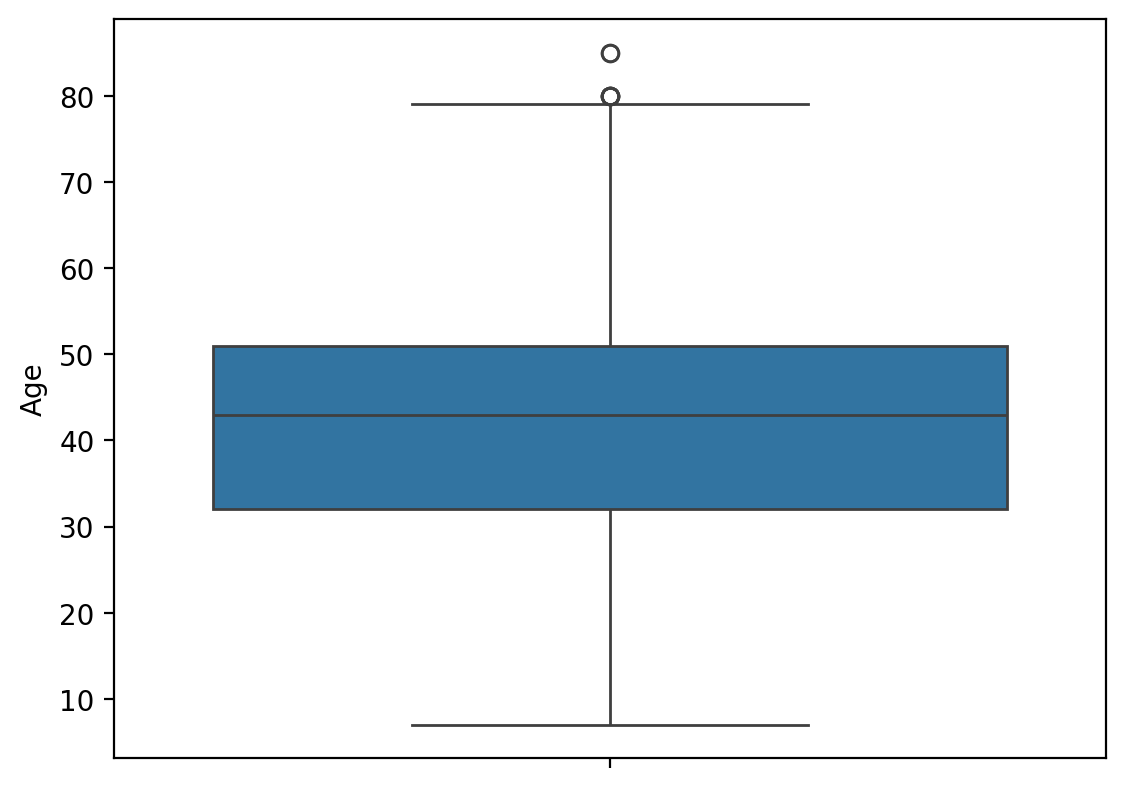

In [ ]:
sns.boxplot(data=data['Age'])

### (2) Target 변수 확인

- Target인 **Satisfaction** 변수에 대해 단변량 분석을 수행합니다.

In [ ]:
print(data['Satisfaction'].value_counts())
print('-' * 25)
print(data['Satisfaction'].value_counts(normalize=True))


Satisfaction
Satisfied                  17293
Neutral or Dissatisfied     1985
Name: count, dtype: int64
-------------------------
Satisfaction
Satisfied                  0.897033
Neutral or Dissatisfied    0.102967
Name: proportion, dtype: float64


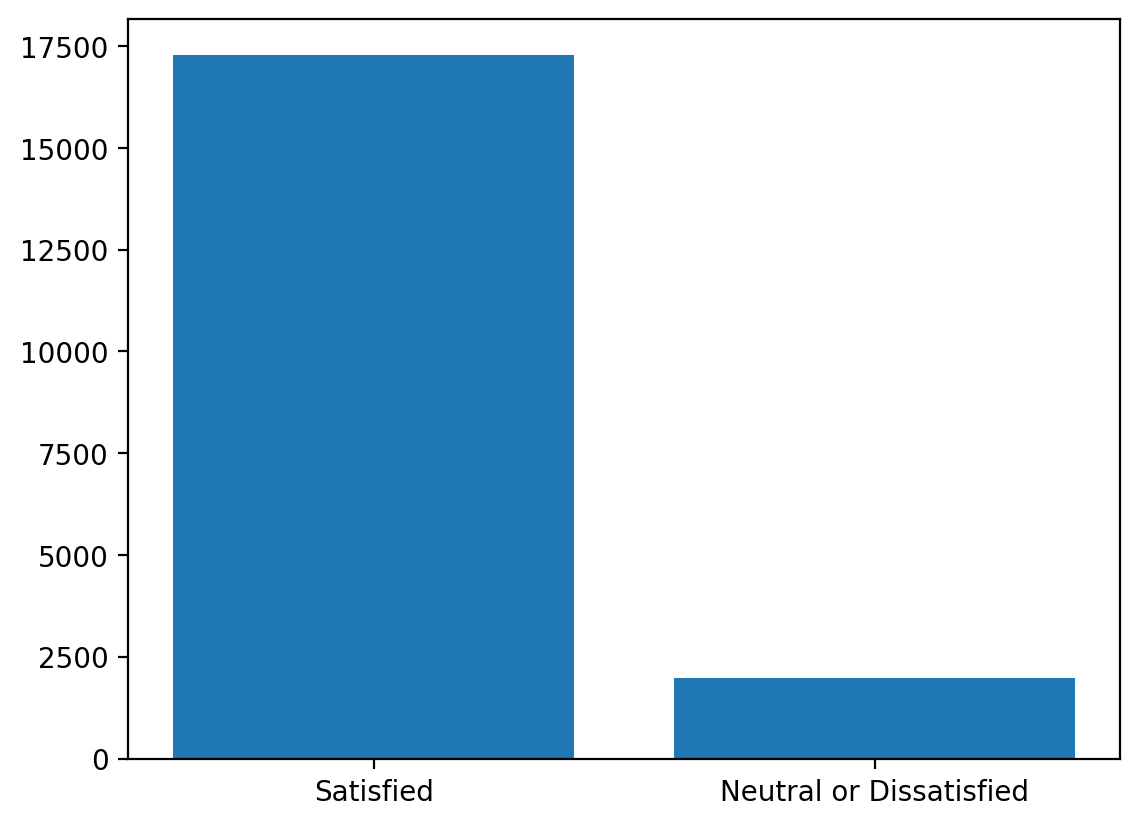

In [ ]:
temp = data['Satisfaction'].value_counts()

plt.bar(x=temp.index, height=temp.values)
plt.show()

### (3) 결측치 확인

- 결측치 비율을 기준으로 내림차순 정렬해 확인합니다.

In [ ]:
data.isnull().mean().sort_values(ascending=False)


,0
Age,0.033821
Inflight wifi service,0.033095
Seat comfort,0.025262
Food and drink,0.019971
Arrival Delay in Minutes,0.002801
Customer Type,0.000000
Unnamed: 0,0.000000
Gender,0.000000
ID,0.000000
Flight Distance,0.000000


### (4) 결측치 채우기

- 결측치가 있는 수치형 변수는 **중앙값**으로, 범주형 변수는 **최빈값**으로 채웁니다.
    - 수치형 변수: 'Age', 'Arrival Delay in Minutes'
    - 범주형 변수: 'Inflight wifi service', 'Seat comfort', 'Food and drink'
- 추천: 이후 확장성을 위해 범주형/수치형 변수를 자동 선택하고, 결측치를 일괄 처리합니다.

In [ ]:
# 수치형 변수 선택
num_cols = data.select_dtypes(include=['number']).columns

# 결측치 → 중앙값
data_meadian = data[num_cols].median()
data[num_cols] = data[num_cols].fillna(data_meadian)

In [ ]:
data[num_cols]

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,80396,16087,35.0,349,5.0,1,1,1,5.0,5,5.0,5,4,2,2,3,1,5,0,0.0
1,20716,125832,40.0,920,1.0,1,1,1,2.0,5,4.0,4,4,4,4,5,4,5,10,3.0
2,29653,40743,52.0,3979,1.0,1,1,1,4.0,1,2.0,4,4,4,4,2,4,4,21,7.0
3,94582,46572,47.0,141,5.0,3,3,3,5.0,5,5.0,3,2,5,5,5,4,5,142,158.0
4,17127,32593,33.0,3153,0.0,5,0,4,3.0,3,3.0,3,3,4,1,1,2,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19273,100323,44888,43.0,2690,2.0,1,2,2,3.0,4,3.0,5,5,5,5,3,5,1,0,5.0
19274,8135,106363,55.0,551,4.0,4,4,4,4.0,4,4.0,4,4,4,4,3,4,4,0,0.0
19275,9293,60995,54.0,649,5.0,5,5,5,2.0,4,5.0,4,4,5,4,5,4,5,1,0.0
19276,102861,108830,46.0,3774,3.0,1,1,1,2.0,4,4.0,4,4,4,4,5,4,3,0,9.0


In [ ]:
# 범주형 변수 선택
cat_cols = data.select_dtypes(include=['object', 'category']).columns

# 결측치 → 최빈값
data_mode = data[cat_cols].mode()
data[cat_cols] = data[cat_cols].fillna(data_mode)


In [ ]:
data[cat_cols]

,Gender,Customer Type,Type of Travel,Class,Satisfaction
0,Male,Loyal Customer,Business Travel,Eco,Satisfied
1,Female,Loyal Customer,Business Travel,Business,Satisfied
2,Female,Loyal Customer,Business Travel,Business,Satisfied
3,Male,Loyal Customer,Business Travel,Eco,Satisfied
4,Male,Loyal Customer,Business Travel,Business,Satisfied
...,...,...,...,...,...
19273,Female,Loyal Customer,Business Travel,Business,Satisfied
19274,Male,Loyal Customer,Business Travel,Business,Satisfied
19275,Female,Loyal Customer,Business Travel,Business,Satisfied
19276,Male,Loyal Customer,Business Travel,Business,Satisfied


In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


### (5) Target 값 변경

- Target인 **Satisfaction** 변수  값을 1과 0으로 변경합니다.
    - 'Satisfied'--> 1,
    - 'Neutral or Dissatisfied' --> 0
- **map()** 메서드를 사용합니다.

In [ ]:
data['Satisfaction'] = data['Satisfaction'].map({'Satisfied' : 1, 'Neutral or Dissatisfied' : 0})


In [ ]:
data['Satisfaction'].unique()

array([1, 0])

### (6) 불필요한 변수 제거

- 다음 변수는 분석에 의미가 없으므로 제거합니다.
    - 'Unnamed: 0'
    - 'ID'

In [ ]:
data.drop('Unnamed: 0', axis=1, inplace=True)
data.drop('ID', axis=1, inplace=True)

In [ ]:
data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,1,1,...,5,4,2,2,3,1,5,0,0.0,1
1,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,1,1,...,4,4,4,4,5,4,5,10,3.0,1
2,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,1,1,...,4,4,4,4,2,4,4,21,7.0,1
3,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,3,3,...,3,2,5,5,5,4,5,142,158.0,1
4,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,0,4,...,3,3,4,1,1,2,3,0,0.0,1


## **3. 미션 2: 가설 수립과 검증**

### (1) 가설 수립

- 'ㅇㅇ이면 ㅇㅇ일 것이다' 라는 형식의 가설을 5개 이상 세워봅니다.
- 이후 분석 과정을 통해 수립한 가설을 검증합니다.
- 특히 이변량 분석을 통해 가설을 검증하도록 합니다.

In [ ]:
# 가설 1: 지연 관련 가설 -> “출발 지연 시간이 길수록 만족도는 낮을 것이다”(Departure Delay vs Satisfaction)
# 가설 2: 서비스 품질 가설 -> “기내 와이파이 서비스 점수가 높을수록 만족도는 높을 것이다”(Inflight wifi service vs Satisfaction)
# 가설 3: 탑승 경험 가설 -> “좌석 편안함 점수가 높을수록 만족도는 높을 것이다” (Seat comfort)
# 가설 4: 온라인 서비스 가설 -> “온라인 체크인/보딩 점수가 높을수록 만족도는 높을 것이다”(Online boarding)
# 가설 5: 청결도 가설 -> “청결도 점수가 높을수록 만족도는 높을 것이다”(Cleanliness)

### (2) 단변량 분석

- 5개 이상의 변수에 대한 단변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

In [ ]:
data['Inflight wifi service'].head()

,Inflight wifi service
0,5.0
1,1.0
2,1.0
3,5.0
4,0.0


Departure Delay in Minutes
0      11397
1        545
2        474
3        375
4        346
       ...  
217        1
244        1
294        1
229        1
750        1
Name: count, Length: 279, dtype: int64
-------------------------
Departure Delay in Minutes
0      0.591192
1      0.028271
2      0.024588
3      0.019452
4      0.017948
         ...   
217    0.000052
244    0.000052
294    0.000052
229    0.000052
750    0.000052
Name: proportion, Length: 279, dtype: float64


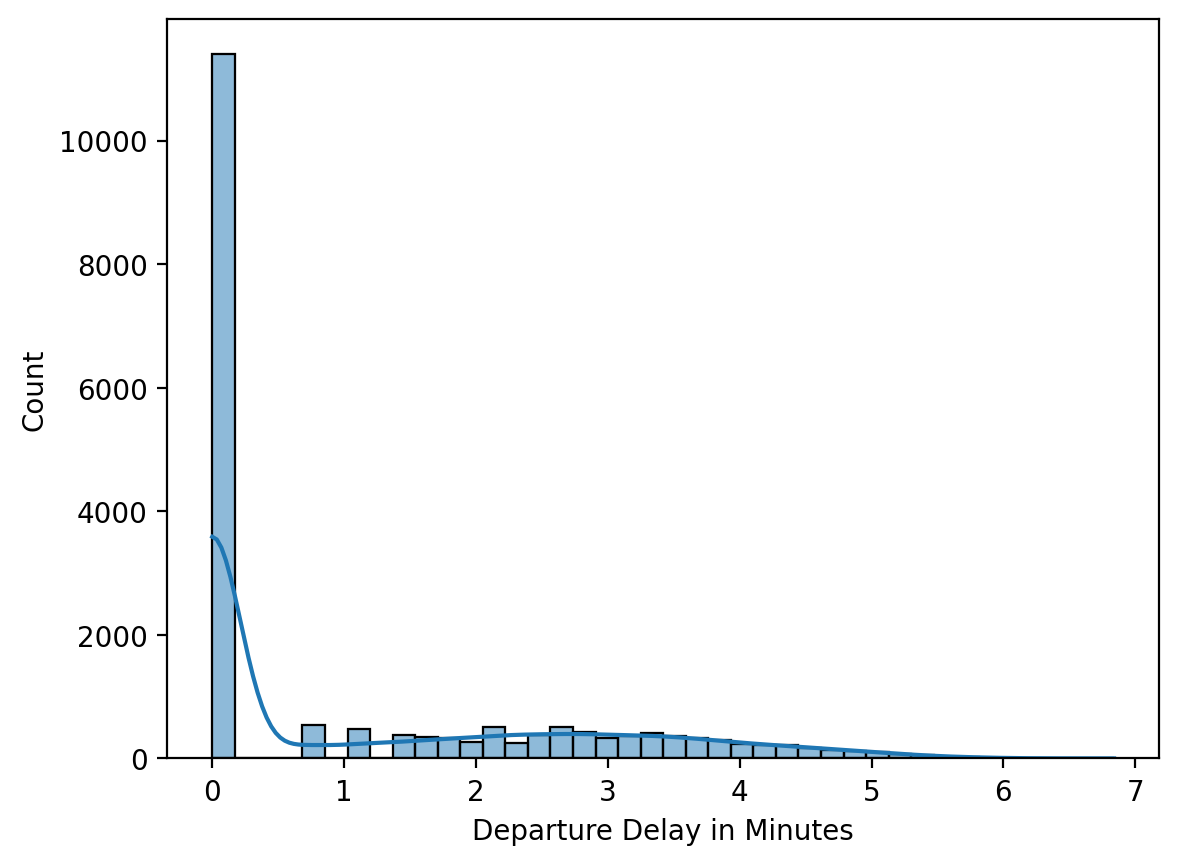

In [ ]:
# 가설 1: 지연 관련 가설
print(data['Departure Delay in Minutes'].value_counts())
print('-' * 25)
print(data['Departure Delay in Minutes'].value_counts(normalize=True))

temp = data['Departure Delay in Minutes'].value_counts()


sns.histplot(np.log1p(data['Departure Delay in Minutes']), kde=True)
plt.show()

# 의견:“출발 지연 시간은 0이 약 59%로 매우 편향된 분포를 보인다.
# 따라서 단순 분포만으로는 만족도와의 관계를 파악하기 어렵고
# 이변량 분석을 통해 추가 검증이 필요하다.”

Inflight wifi service
4.0    4712
5.0    4192
3.0    3750
2.0    3022
1.0    2494
0.0    1108
Name: count, dtype: int64
-------------------------
Inflight wifi service
4.0    0.244424
5.0    0.217450
3.0    0.194522
2.0    0.156759
1.0    0.129370
0.0    0.057475
Name: proportion, dtype: float64


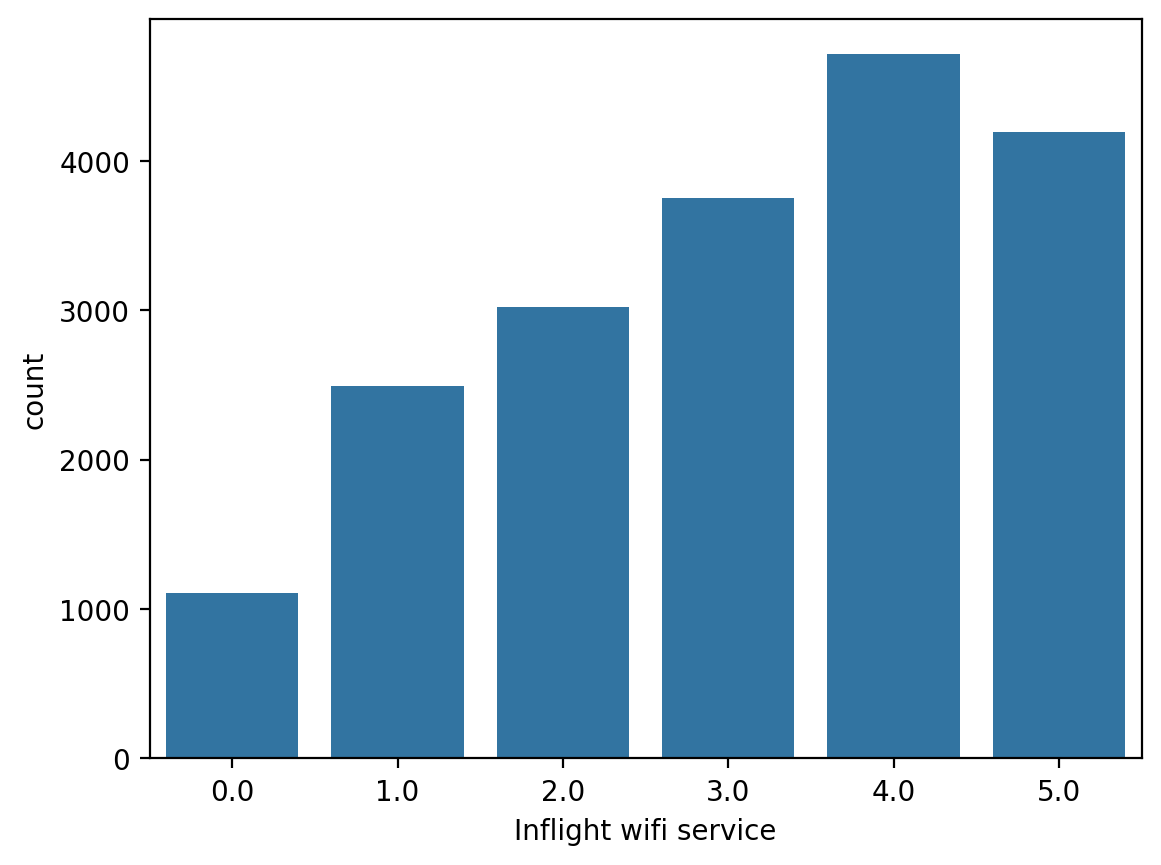

In [ ]:
print(data['Inflight wifi service'].value_counts())
print('-' * 25)
print(data['Inflight wifi service'].value_counts(normalize=True))

temp = data['Inflight wifi service'].value_counts()


sns.countplot(x='Inflight wifi service', data=data)
plt.show()

Seat comfort
4.0    7630
5.0    6784
3.0    1957
2.0    1566
1.0    1341
Name: count, dtype: int64
-------------------------
Seat comfort
4.0    0.395788
5.0    0.351904
3.0    0.101515
2.0    0.081232
1.0    0.069561
Name: proportion, dtype: float64


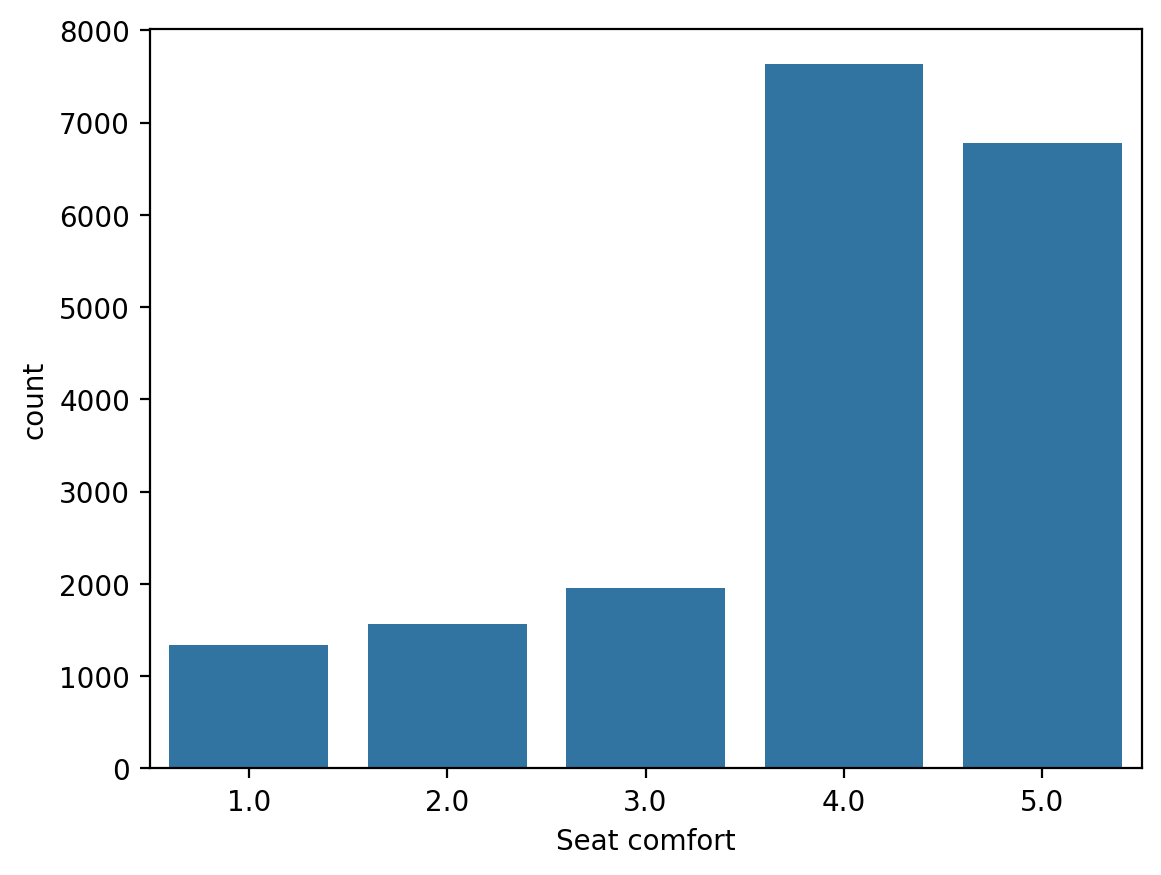

In [ ]:
print(data['Seat comfort'].value_counts())
print('-' * 25)
print(data['Seat comfort'].value_counts(normalize=True))

temp = data['Seat comfort'].value_counts()


sns.countplot(x='Seat comfort', data=data)
plt.show()

Online boarding
4    7851
5    6965
3    1764
2    1269
1     893
0     536
Name: count, dtype: int64
-------------------------
Online boarding
4    0.407252
5    0.361293
3    0.091503
2    0.065826
1    0.046322
0    0.027804
Name: proportion, dtype: float64


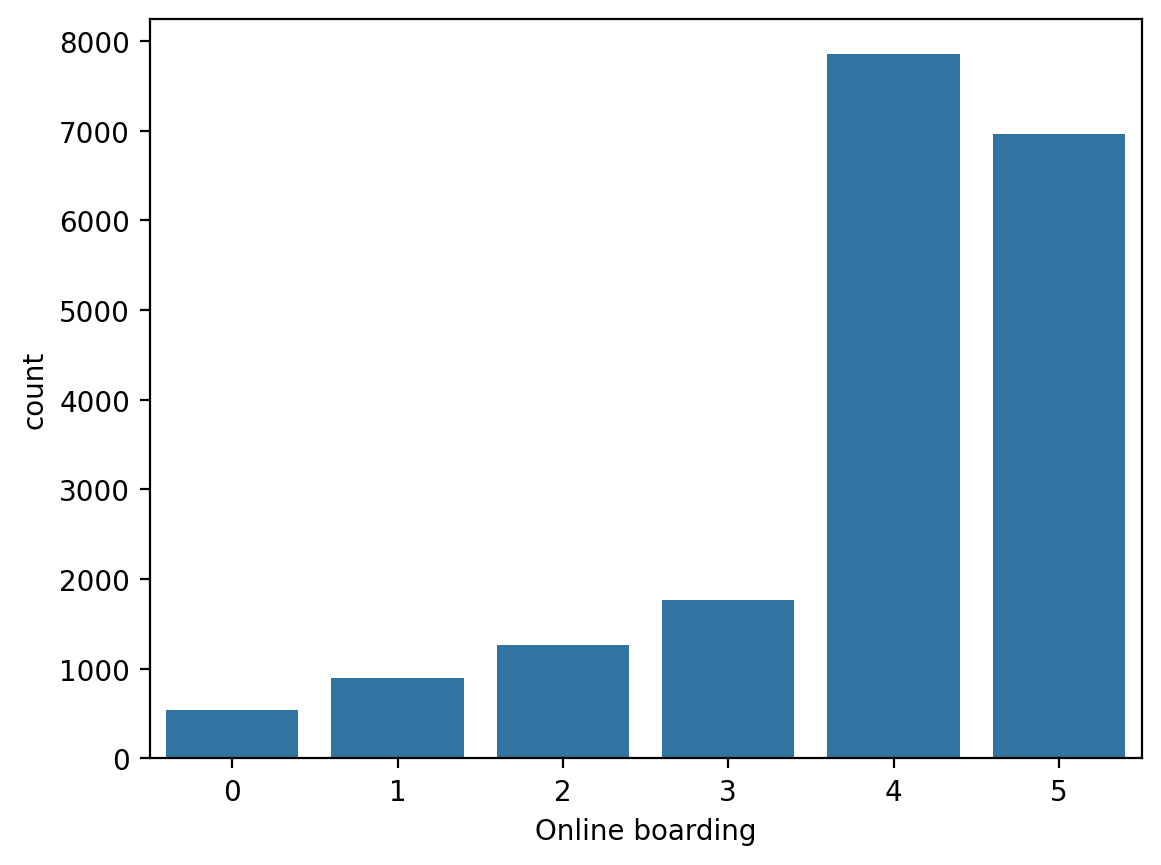

In [ ]:
print(data['Online boarding'].value_counts())
print('-' * 25)
print(data['Online boarding'].value_counts(normalize=True))

temp = data['Online boarding'].value_counts()


sns.countplot(x='Online boarding', data=data)
plt.show()

Cleanliness
4    6073
5    5552
3    4542
2    1730
1    1381
Name: count, dtype: int64
-------------------------
Cleanliness
4    0.315022
5    0.287997
3    0.235605
2    0.089740
1    0.071636
Name: proportion, dtype: float64


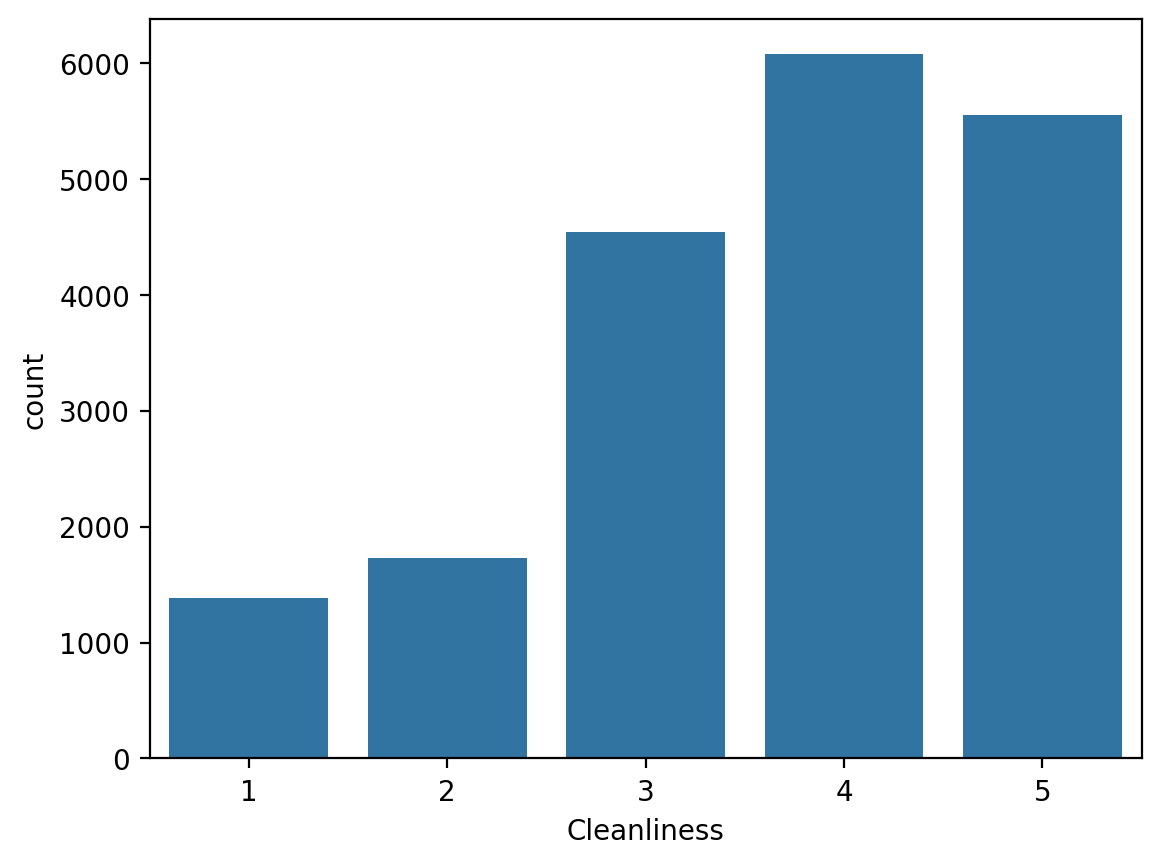

In [ ]:
print(data['Cleanliness'].value_counts())
print('-' * 25)
print(data['Cleanliness'].value_counts(normalize=True))

temp = data['Cleanliness'].value_counts()


sns.countplot(x='Cleanliness', data=data)
plt.show()

In [ ]:
#의견:“1번가설 외 서비스 품질 변수들은 특정 값(4점)에 집중된 분포를 보여 변별력이 낮은 특징을 가진다.
# 이러한 특성은 모델링 시 변수의 영향력을 약화시킬 수 있으므로
# 타겟 변수와의 관계를 추가적으로 분석할 필요가 있다.”

### (3) 이변량 분석

- 5개 이상의 이변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

In [ ]:
data[['Satisfaction', 'Departure Delay in Minutes']].corr()

,Satisfaction,Departure Delay in Minutes
Satisfaction,1.000000,-0.029975
Departure Delay in Minutes,-0.029975,1.000000


<Axes: xlabel='Satisfaction', ylabel='Departure Delay in Minutes'>

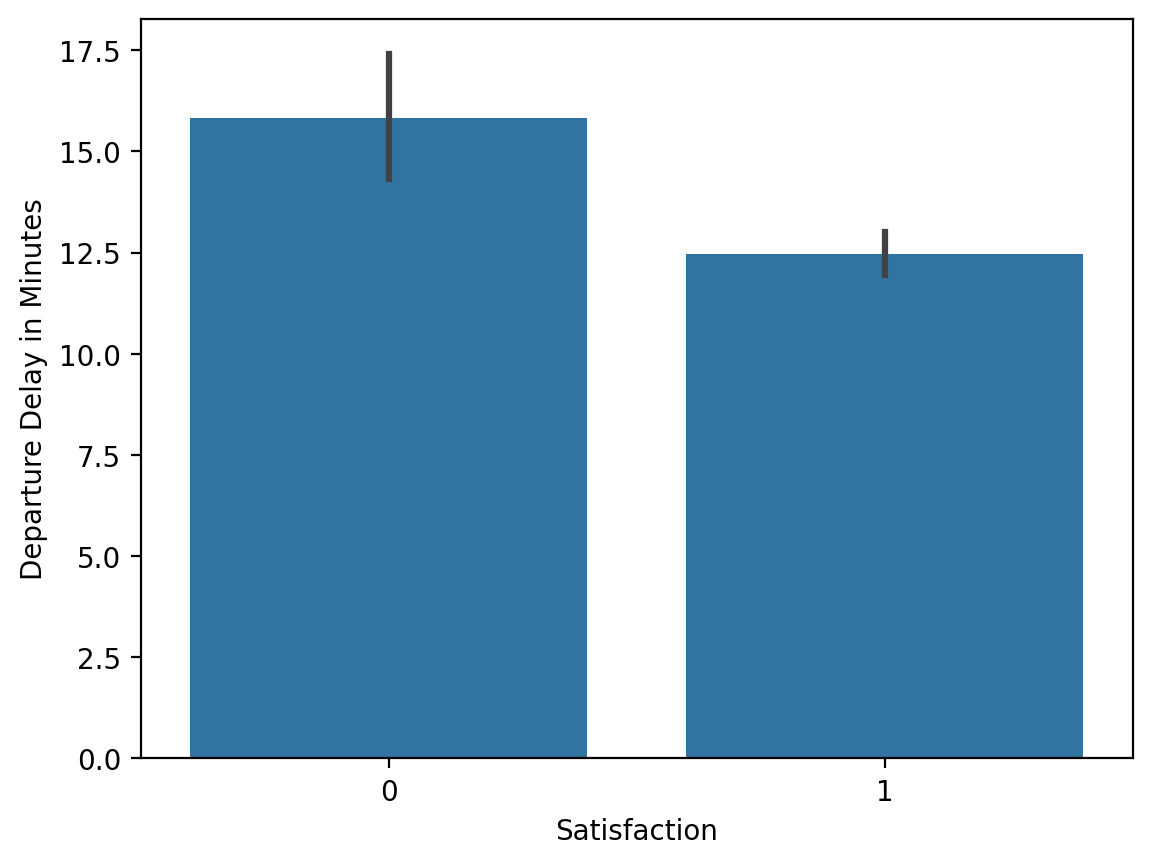

In [100]:
sns.barplot(x='Satisfaction', y='Departure Delay in Minutes', data=data)
# 의견:“산점도를 통해 출발 지연 시간과 만족도의 관계를 확인하고자 하였으나,
# 만족도 변수가 이진값(0,1)으로 구성되어 있어 데이터가 두 개의 수평선 형태로 분포하였다.
# 이로 인해 두 변수 간의 관계를 직관적으로 파악하기 어렵기 때문에
# 추가적인 이변량 분석(박스플롯, 평균 비교 등)이 필요하다.”

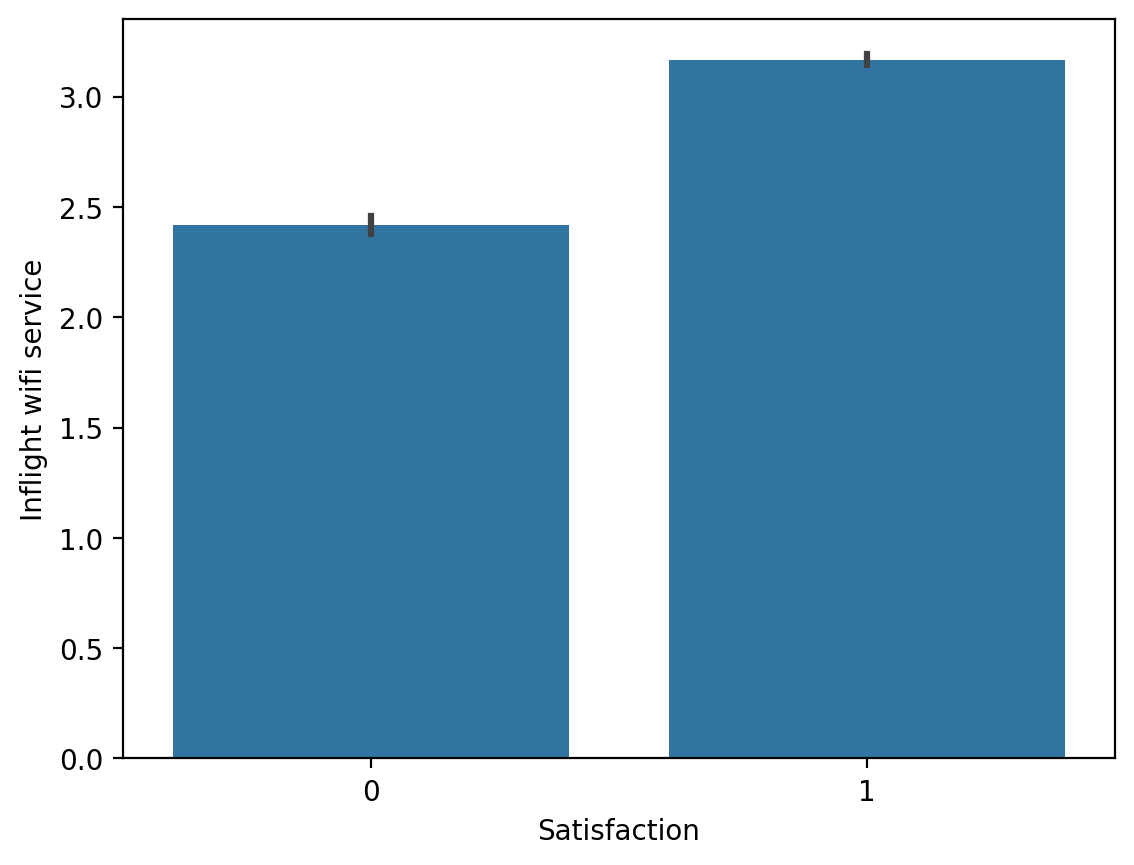

In [101]:
sns.barplot(x='Satisfaction', y='Inflight wifi service', data=data)
plt.show()

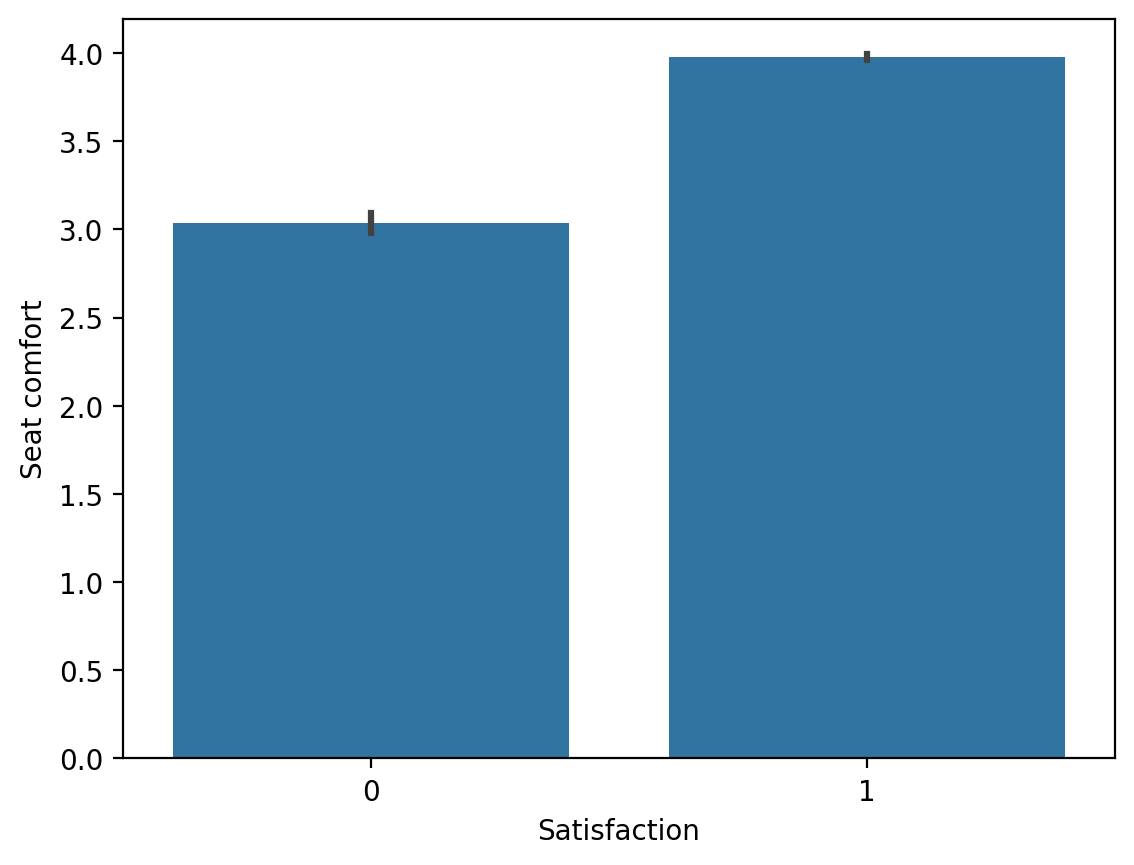

In [102]:
sns.barplot(x='Satisfaction', y='Seat comfort', data=data)
plt.show()

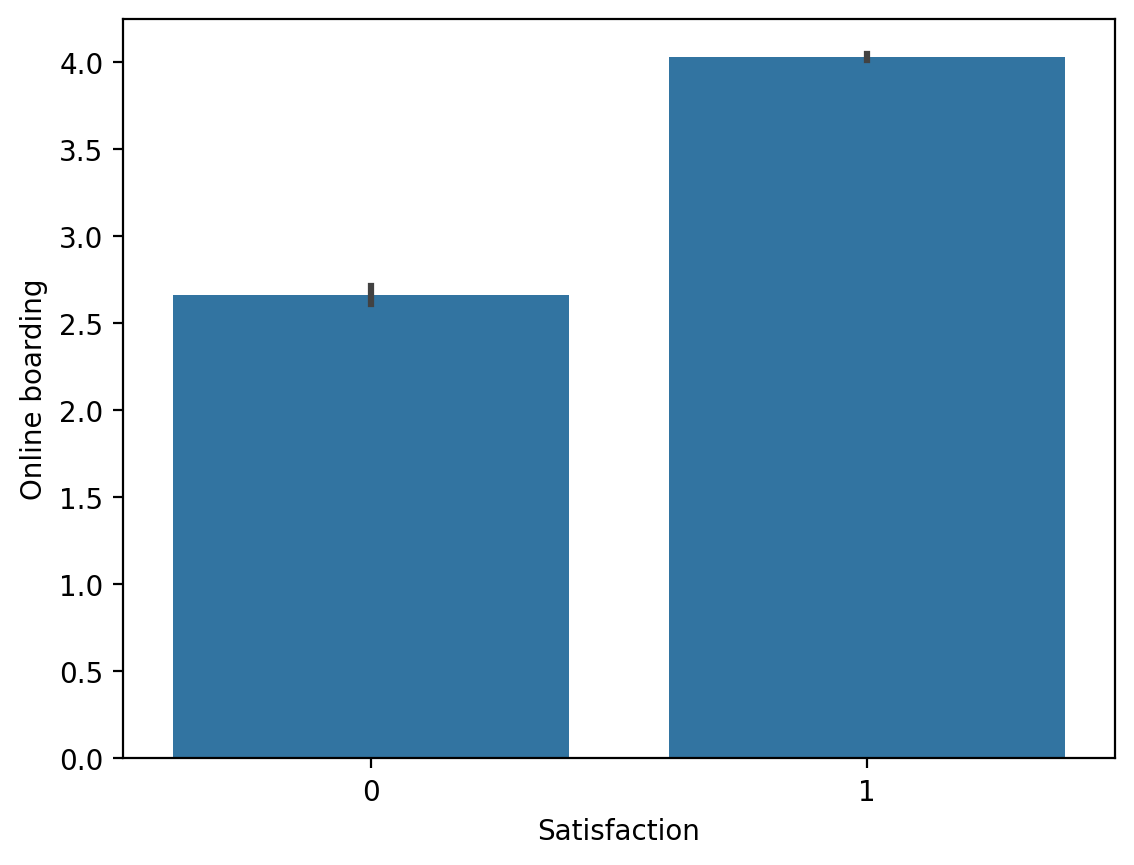

In [103]:
sns.barplot(x='Satisfaction', y='Online boarding', data=data)
plt.show()

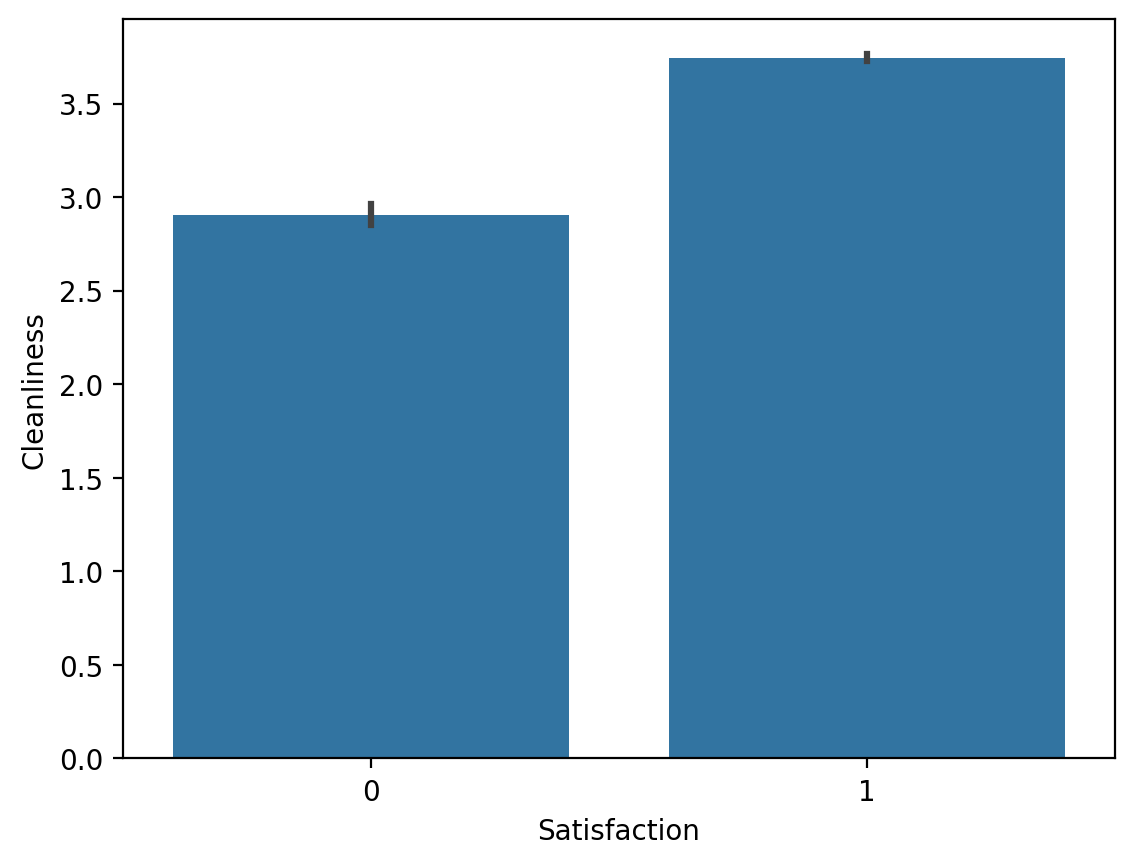

In [104]:
sns.barplot(x='Satisfaction', y='Cleanliness', data=data)
plt.show()

#그외 나머지의 경우 종종 이상치들이 발견되는데 추후 조치가 필요해보인다

## **4. 미션 3: 머신러닝 모델링 #1**

- Tree 기반 알고리즘을 사용해야 **변수 중요도**를 확인할 수 있습니다.
- **RandomForest** 알고리즘을 사용해 머신러닝 모델을 만들고 성능을 평가합니다.
- **변수 중요도**를 확인해 추가 분석 대상 변수를 선정합니다.

### (1) 전처리

- 최소한 문자열 데이터가 없어야 하고, 결측치도 없도록 전처리해야 합니다.
- 결측치는 이전 단계에서 처리한 상태입니다.
- 범주형 변수에 대해 **LabelEncoder**를 사용해 인코딩합니다.
- 변수 중요도를 확인하기 위함이므로 가변수화를 하지 않습니다.

In [ ]:
# 변수 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  object 
 1   Customer Type                      19278 non-null  object 
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  object 
 4   Class                              19278 non-null  object 
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

In [ ]:
# 문자열 변수 리스트로 선언
cat_cols =['Gender','Customer Type','Type of Travel','Class']

# 라벨 인코딩
for col in cat_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])

- info() 메서드로 변수 정보를 다시 확인합니다.
- **Dtype에 object 형식의 열이 있으면 이후 과정을 진행할 수 없습니다.**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  int64  
 1   Customer Type                      19278 non-null  int64  
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  int64  
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

- target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
target = 'Satisfaction'
x = data.drop(target, axis=1)
y = data.loc[:,target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=1)


### (2) 모델링

- 머신러닝 모델링을 수행합니다.
- 검증 데이터로 예측하고 성능을 평가해 봅니다.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier()

In [ ]:
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(x_val)

In [ ]:
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val,y_pred))

#“Decision Tree 모델을 활용한 분류 결과, 전체 정확도는 약 95%로 높은 성능을 보였다.
# 특히 만족 클래스에 대해서는 높은 precision과 recall을 기록하였다.
# 그러나 불만족 클래스의 경우 상대적으로 낮은 성능을 보여 클래스 불균형의 영향이 존재하는 것으로 판단된다.”

[[ 468  113]
 [ 153 5050]]
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       581
           1       0.98      0.97      0.97      5203

    accuracy                           0.95      5784
   macro avg       0.87      0.89      0.88      5784
weighted avg       0.96      0.95      0.95      5784



### (3) 변수 중요도 확인

- 변수 중요도를 시각화해 확인합니다.

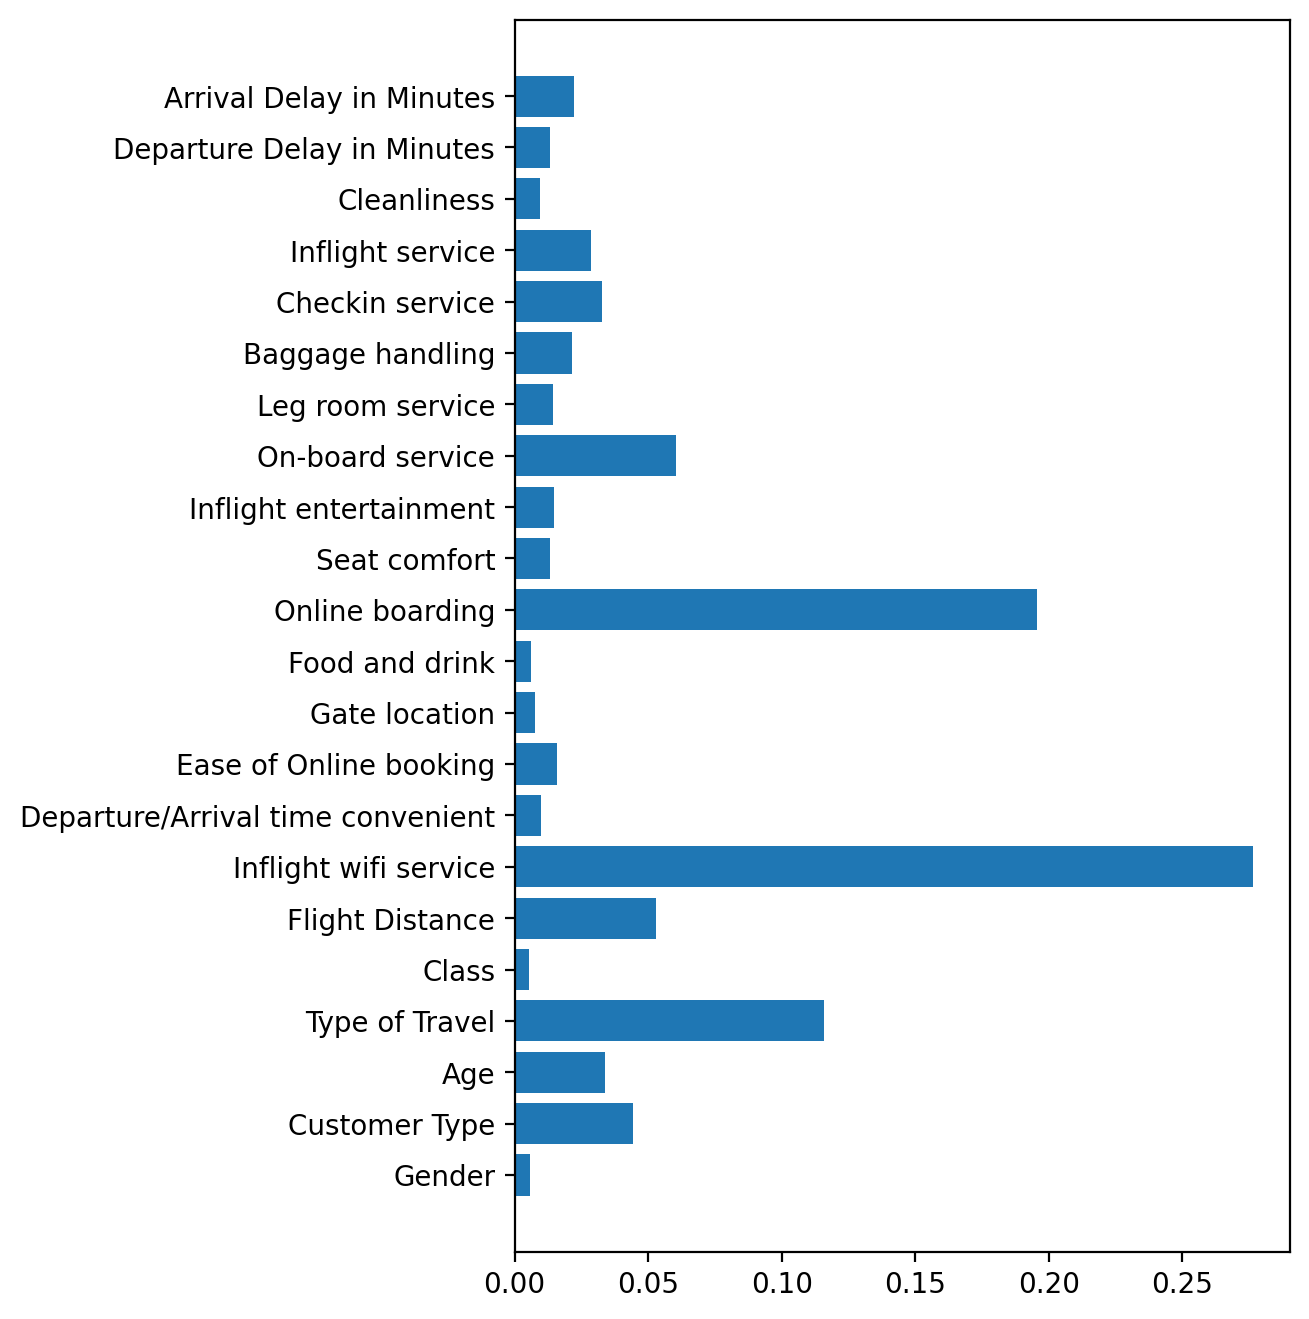

In [ ]:
plt.figure(figsize=(5, 8))
plt.barh(list(x), model.feature_importances_)
plt.show()
# “Feature importance 분석 결과, 기내 와이파이 서비스와 온라인 보딩과 같은 디지털 서비스 관련 변수가
# 만족도에 가장 큰 영향을 미치는 것으로 나타났다. 반면, 출발 및 도착 지연과 같은 시간 관련 변수는
# 상대적으로 낮은 중요도를 보여, 고객 만족도에 미치는 영향이 제한적인 것으로 판단된다.”

### (4) 결과 정리

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 1.Inflight wifi service
# 2. Online boarding
# 3. Type of Travel
# 4. On_borad service
# 5. Flight Distance

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 1.Gender
# 2.Class
# 3.Gate location
# 4.Food and drink
# 5.Departure Delay in Minutes

## **5. 미션 4: 머신러닝 모델링 #2**

- 35세를 기준으로 데이터를 분리해 각각에 대한 모델을 만들어봅니다.

### (1) 데이터 분리

- 더 세분화할 수 있지만, 35세를 기준으로 두 개의 데이터프레임을 만듭니다.
    - **data01**: Age <= 35
    - **data02**: Age > 35

In [ ]:
# 데이터 분리
data01 = data.loc[data['Age'] <= 35,:]
data02 = data.loc[data['Age'] > 35,:]

### (2) 35세 이하 모델링

- **data01** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
target = 'Satisfaction'
x = data01.drop(target, axis = 1)
y = data01.loc[:,target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=1)


- 모델링을 수행합니다.

In [ ]:
model = DecisionTreeClassifier()

In [ ]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(x_val)

In [ ]:
print(confusion_matrix(y_val,y_pred))
print(classification_report(y_val,y_pred))

[[ 462  119]
 [ 171 5032]]
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       581
           1       0.98      0.97      0.97      5203

    accuracy                           0.95      5784
   macro avg       0.85      0.88      0.87      5784
weighted avg       0.95      0.95      0.95      5784



- 변수 중요도를 확인합니다.

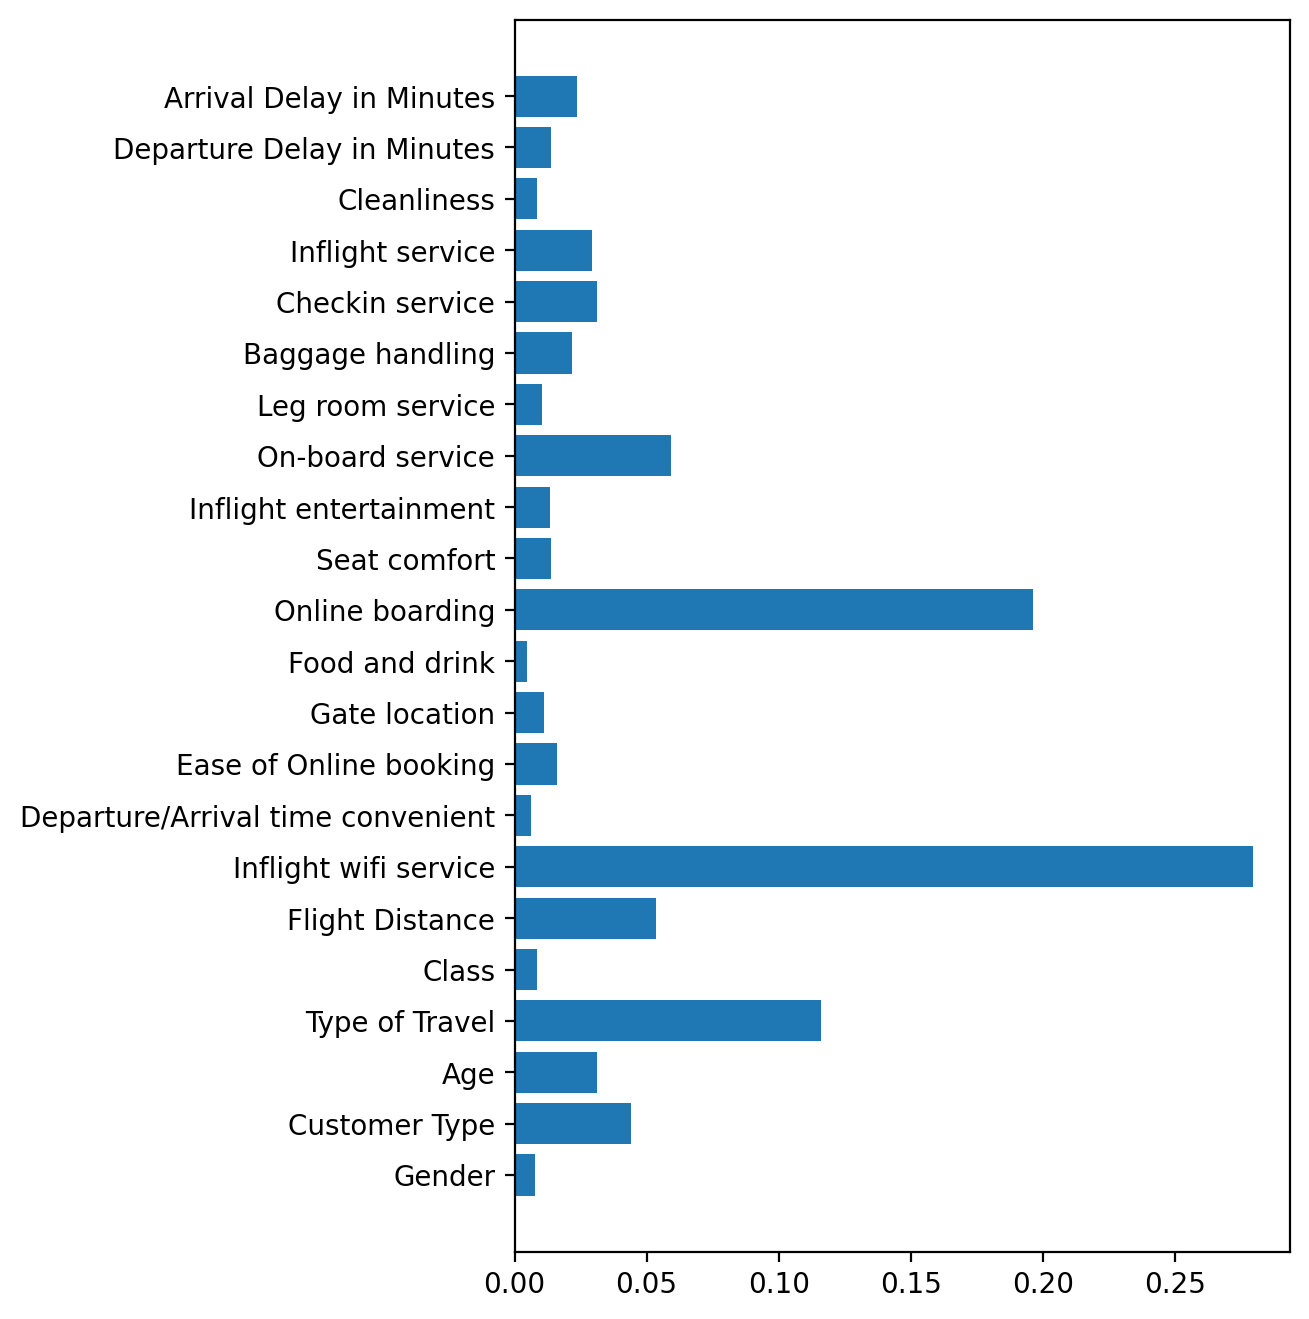

In [ ]:
plt.figure(figsize=(5, 8))
plt.barh(list(x), model.feature_importances_)
plt.show()

- 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 1.Inflight wifi service
# 2.Online boarding
# 3.On-board service
# 4.Type fo Travel
# 5.Flight Distance

- 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 1.Food and drink
# 2.Departure/Arrival time convenient
# 3.Class
# 4.Gender
# 5.Cleanliness

### (3) 35세 초과 모델링

- **data02** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
target = 'Satisfaction'
x = data02.drop(target, axis=1)
y = data02.loc[:,target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
x_train,x_val,y_train,y_val = train_test_split(x, y, test_size=0.3, random_state=1)


- 모델링을 수행합니다.

In [ ]:
model = DecisionTreeClassifier()


In [ ]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(x_val)

In [ ]:
print(confusion_matrix(y_val,y_pred))
print(classification_report(y_val,y_pred))

[[ 464  117]
 [ 161 5042]]
              precision    recall  f1-score   support

           0       0.74      0.80      0.77       581
           1       0.98      0.97      0.97      5203

    accuracy                           0.95      5784
   macro avg       0.86      0.88      0.87      5784
weighted avg       0.95      0.95      0.95      5784



- 변수 중요도를 확인합니다.

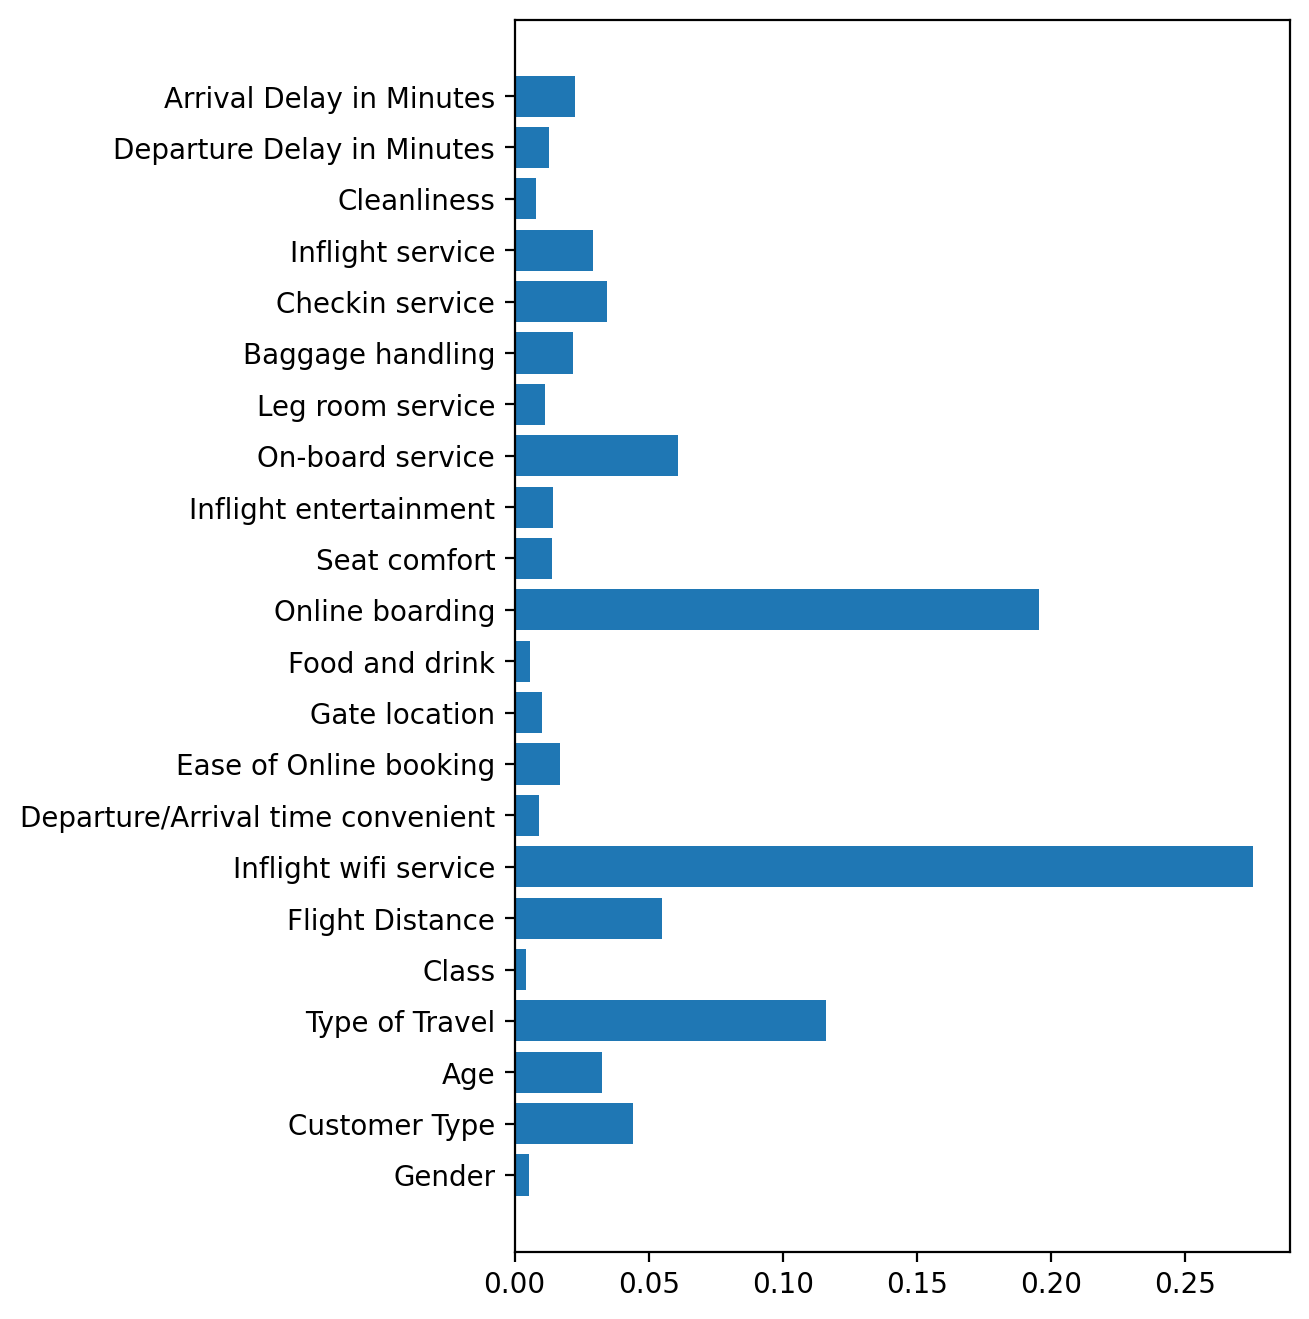

In [ ]:
plt.figure(figsize=(5, 8))
plt.barh(list(x), model.feature_importances_)
plt.show()


- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 1.Inflight wifi service
# 2.Online boarding
# 3.On-board service
# 4.Type fo Travel
# 5.Flight Distance

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 1.Food and drink
# 2.Departure/Arrival time convenient
# 3.Class
# 4.Gender
# 5.Cleanliness

### (4) 의견 정리

- 위 모델링 과정과 변수 중요도 확인 과정 결과에 대한 의견을 정리합니다.

In [ ]:
#“연령을 기준으로 데이터를 분리하여 분석한 결과, 모델 성능과 주요 변수의 영향이 큰 차이를 보이지 않았다.
# 이는 연령 변수 자체의 중요도가 상대적으로 낮고, 고객 만족도에 더 큰 영향을 미치는 서비스 품질 변수들이
# 연령과 관계없이 유사한 패턴을 보이기 때문으로 판단된다.”

## **6. 미션 5: 데이터 분석**

- 위에서 확인된 변수 중요도를 기준으로 분석할 변수를 5개 선정하고 분석을 수행합니다.
- **data** 데이터프레임을 대상으로 분석합니다.
- Satisfaction 변수와의 **이변량 분석**에 중점을 두고 수행합니다.
- 각 분석 결과에 대한 의견을 주석으로 정리합니다.

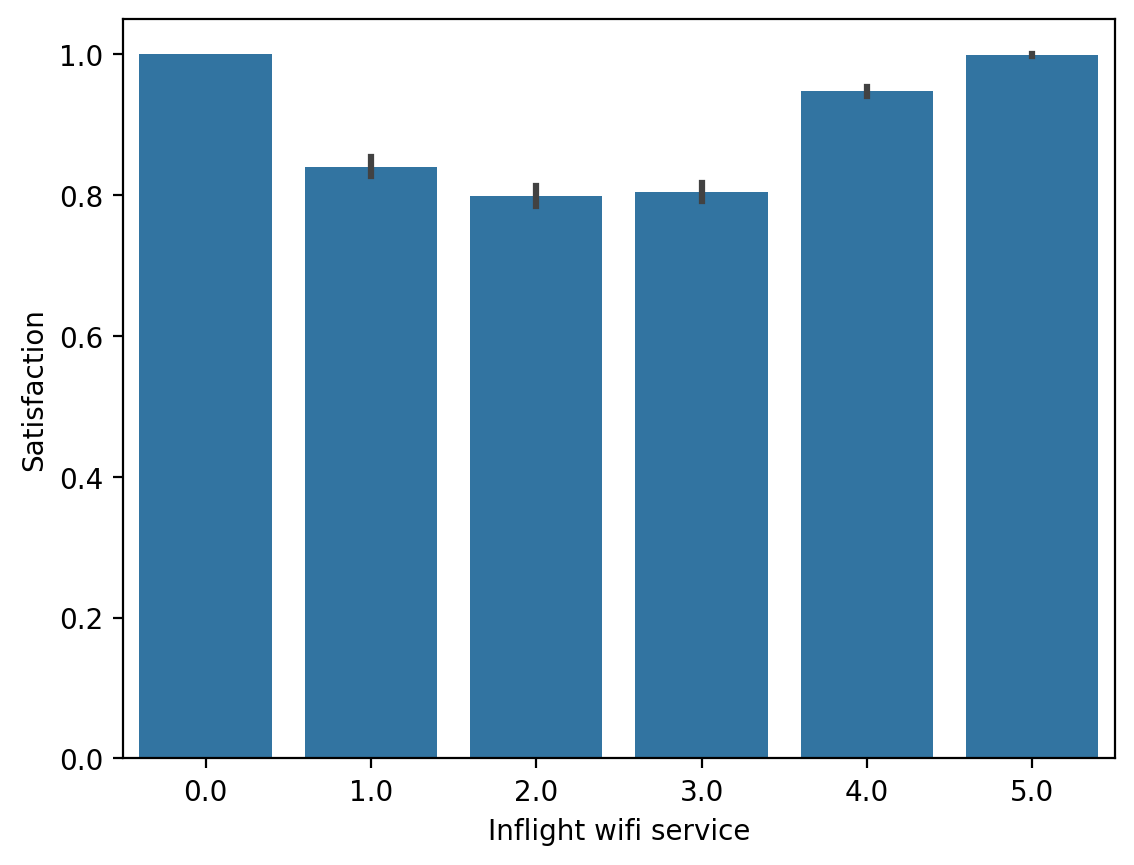

In [ ]:
sns.barplot(x='Inflight wifi service', y='Satisfaction', data=data)
plt.show()

# 의견:
# 와이파이 점수가 높아질수록 Satisfaction(만족도)이 증가하는 경향을 보인다.
# 특히 3점 이하에서는 만족도가 낮고, 4~5점 구간에서 급격히 상승한다.
# → 고객 만족도에 가장 큰 영향을 미치는 핵심 변수로 판단된다.

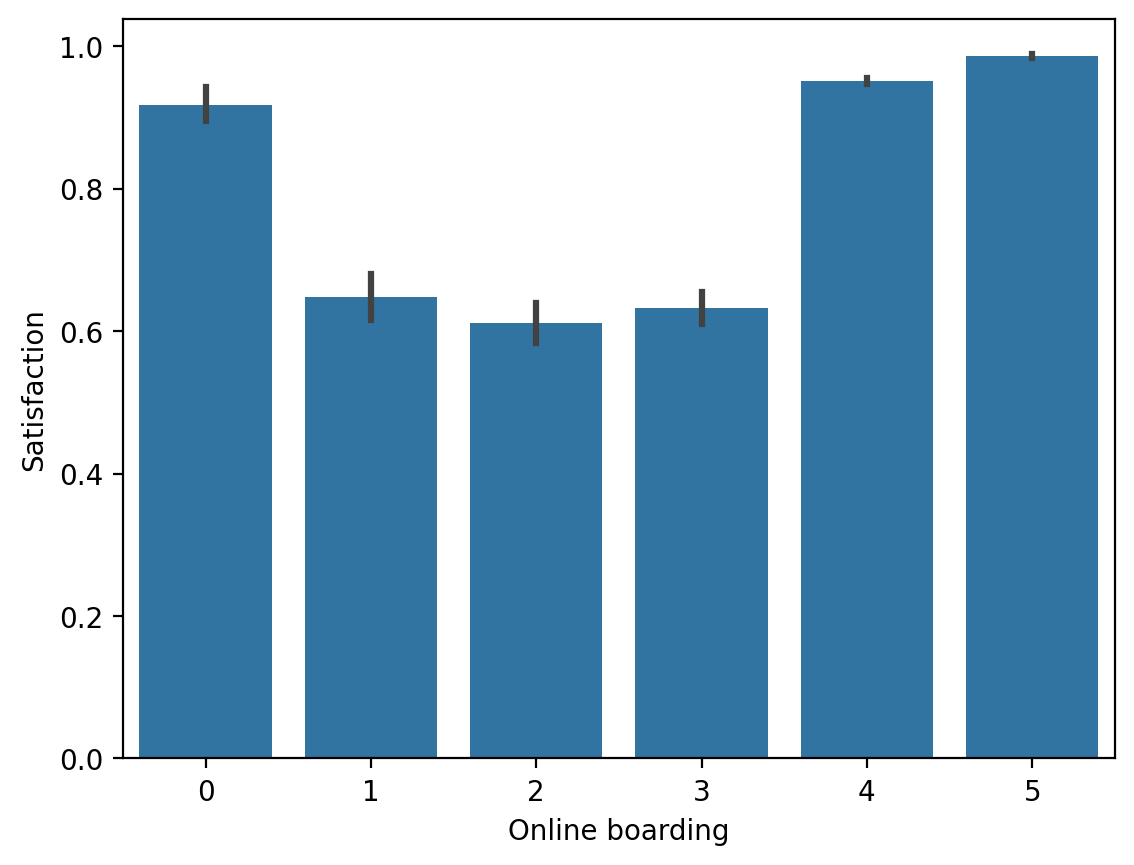

In [ ]:
sns.barplot(x='Online boarding', y='Satisfaction', data=data)
plt.show()

# 의견:
# 온라인 탑승수속 점수가 높을수록 만족도가 증가하는 뚜렷한 패턴이 나타난다.
# 기내 서비스가 고객 만족에 중요한 요소임을 확인할 수 있다.

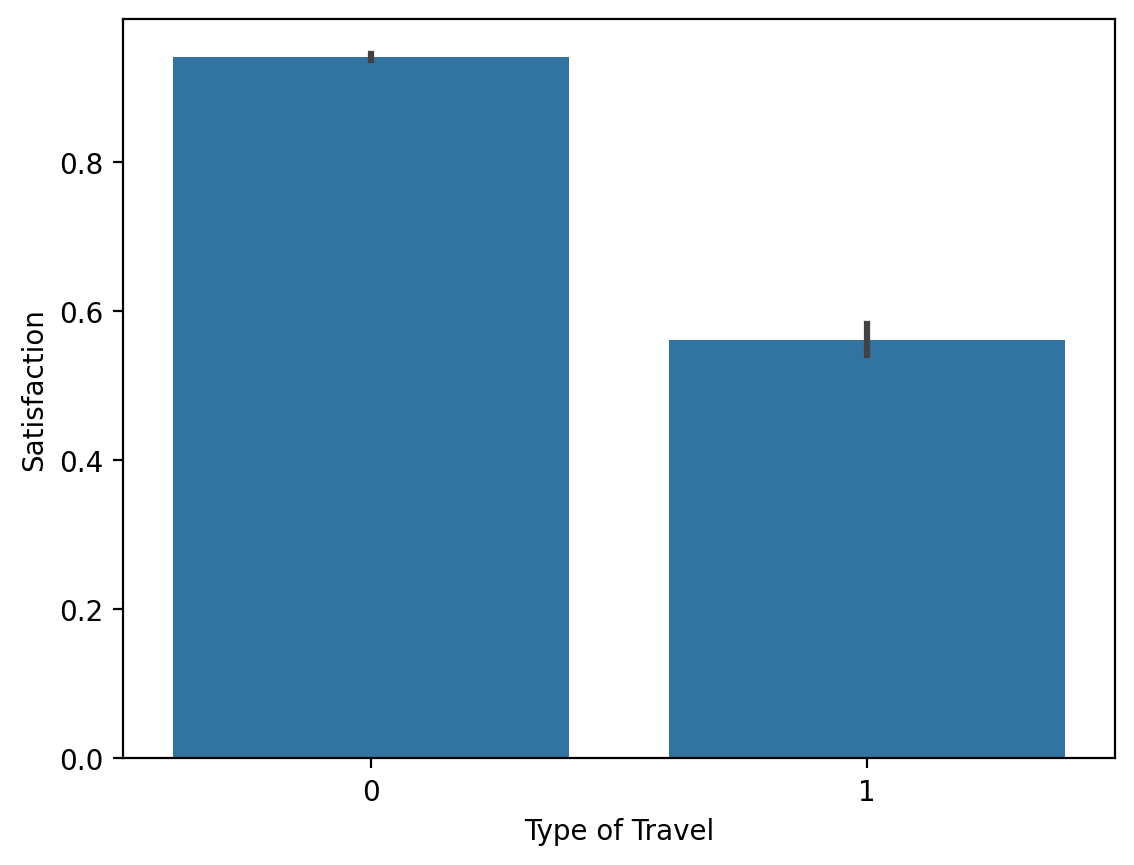

In [ ]:
sns.barplot(x='Type of Travel', y='Satisfaction', data=data)
plt.show()

# 의견:
# 여행 유형에 따라 만족도 차이가 존재한다.
# 일반적으로 Business travel이 Personal travel보다 만족도가 높은 경향을 보인다.
# → 고객 유형에 따라 서비스 전략 차별화 필요

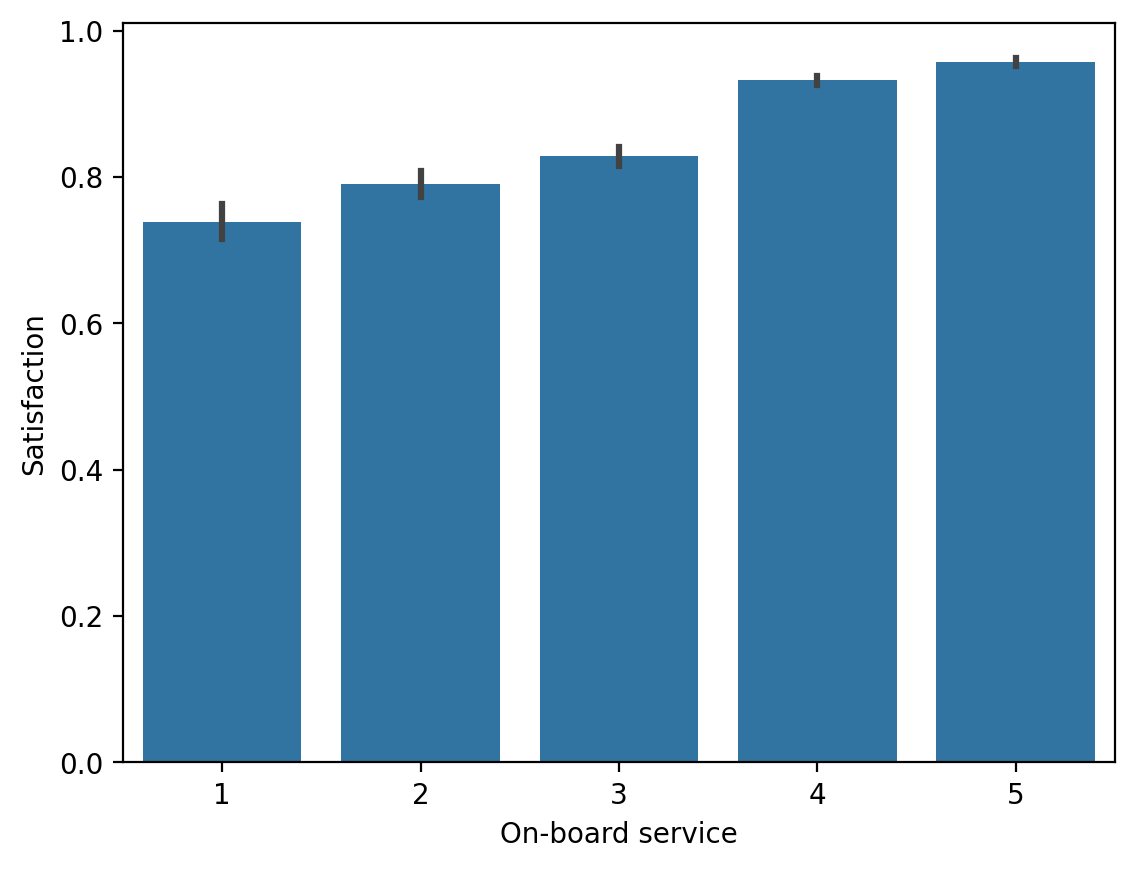

In [ ]:
sns.barplot(x='On-board service', y='Satisfaction', data=data)
plt.show()

# 의견:
# 기내 서비스 점수가 높을수록 만족도가 증가한다.
# 다만 와이파이/보딩보다는 영향력이 다소 낮지만, 여전히 중요한 변수이다.

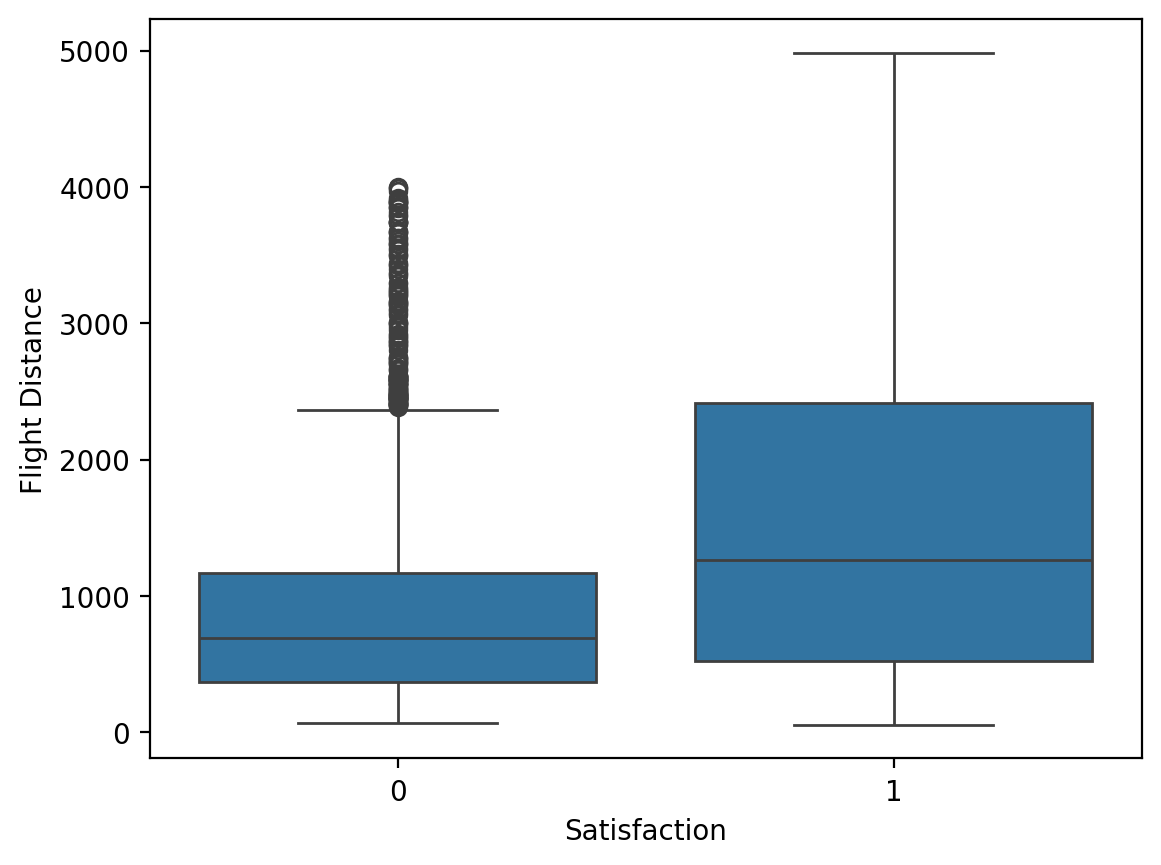

In [ ]:
sns.boxplot(x='Satisfaction', y='Flight Distance', data=data)
plt.show()

# 의견:
# 비행 거리와 만족도 간의 관계는 뚜렷하지 않다.
# 일부 차이는 존재하지만, 서비스 변수에 비해 영향력이 제한적인 것으로 보인다.
# 비행 거리 변수는 일부 값이 이상치로 나타났으나
# 이는 실제 항공 데이터의 특성상 단거리와 장거리 비행이 혼합되어 발생한 자연스러운 분포로 판단된다.

## **7. 저장하기**

- **to_csv()** 메서드를 사용해 이후 과정을 위해 data 데이터프레임을 **project01** 폴더에 저장합니다.
    - index=False 옵션 지정
    - data → path + 'data.csv'
    
- 저장된 파일을 필히 확인합니다.

In [ ]:
# 파일 저장
data.to_csv(path + 'data.csv', index=False)